**<center><font size=10>Stock Market Sentiment Analysis using Generative AI</center></font>**

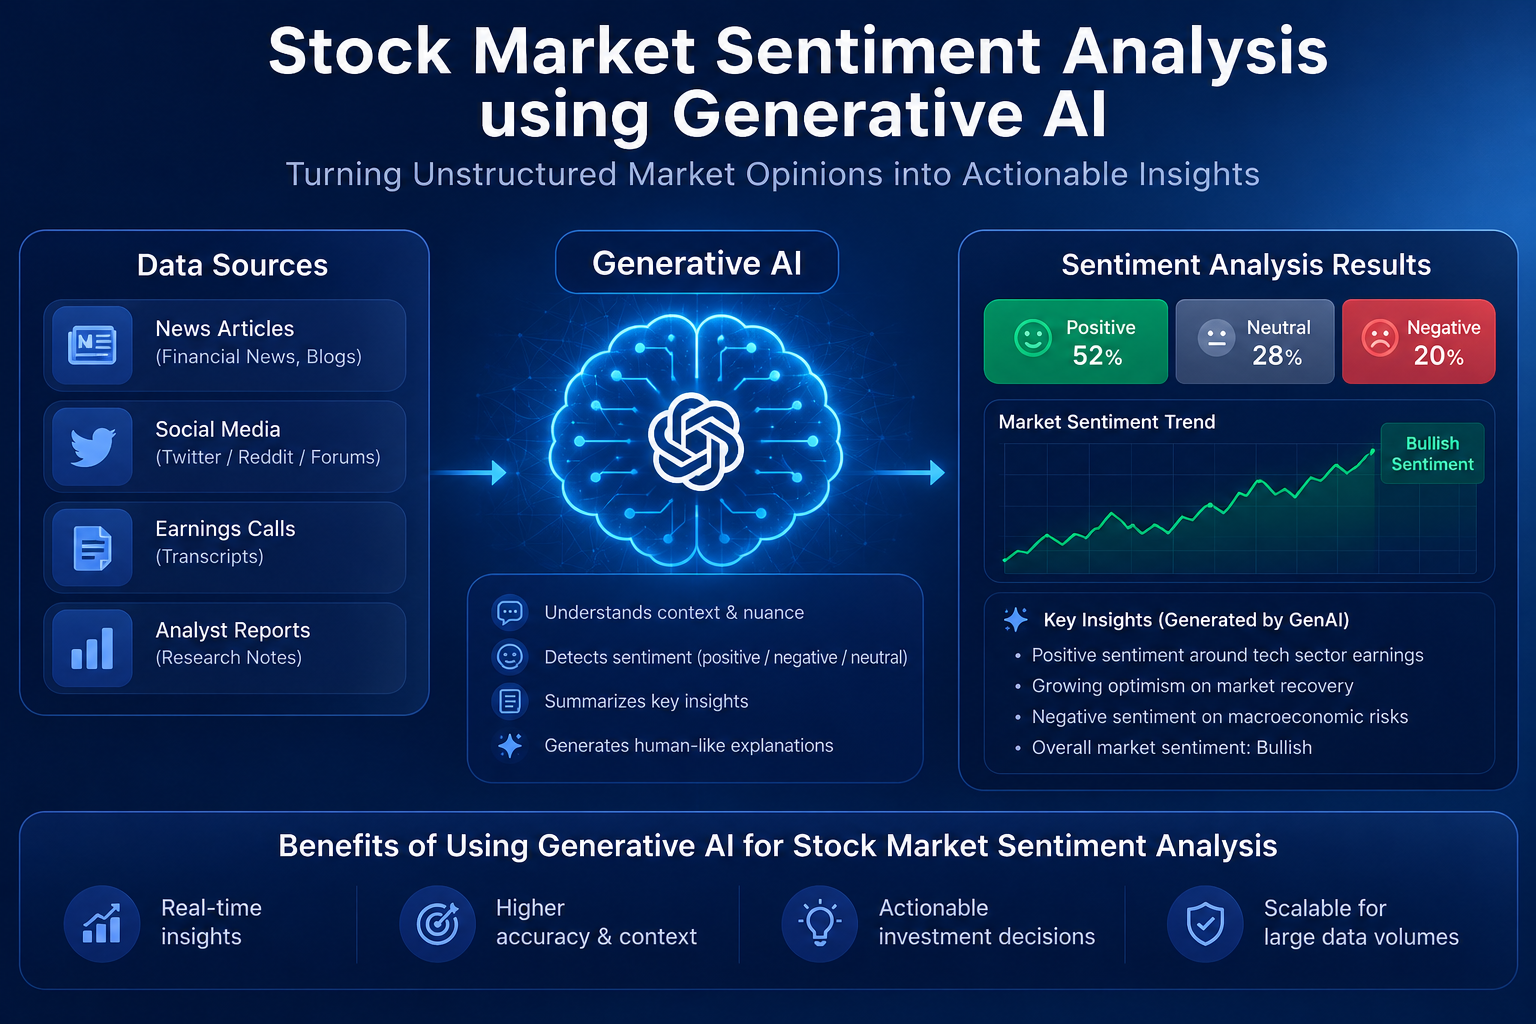

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

# Key Insights



*   **Data Quality & Trends:** Clean data; news articles consistently 40-60 words. Stock prices rose steadily Jan-Apr 2019, with fluctuating volume.
*   **Feature Correlation:** A correlation matrix identified relationships between numeric variables (prices, volume, news length) and sentiment.
*   **Sentiment's Price Impact:** Box plots revealed potential links between news sentiment polarity and stock price distributions.
*   **Contextual Embeddings Superior:** Sentence Transformer embeddings (BAAI/bge-base-en-v1.5, all-MiniLM-L6-v2) consistently outperformed Word2Vec.
*   **Best Model:** The Neural Network with Sentence Transformer (all-MiniLM-L6-v2) achieved the highest test accuracy (0.557) and F1-score (0.551).

## **Installing and Importing the necessary libraries**

 Here’s what we’ll be using:

- **Pandas:** Used for all data loading, manipulation, and initial exploratory analysis (e.g., creating News_Length).
- **Numpy:** Fundamental for numerical operations, especially when handling and processing text embeddings.
- **Sentence-transformers:** Critical for generating advanced, contextual text embeddings from news articles.
- **Scikit-learn:** Employed for splitting data, building Random Forest models, and evaluating all classification metrics.
- **Tensorflow (with Keras):** Utilized to build and train the Neural Network models, which showed strong performance

In [ ]:
# Install the five most important libraries
!pip install pandas numpy scikit-learn sentence-transformers tensorflow

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
!pip install gensim
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.5 MB/s eta 0:00:00


## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GENAI/stock_news.csv")

In [6]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

 Displays the first five rows of the dataset to get a quick overview of the data.

In [8]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [9]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [10]:
data.shape

(349, 8)

Returns the number of rows and columns in the dataset.

###**Checking for missing values**

In [11]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [12]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

**Exploratory** Data Analysis (EDA) is the process of examining and visualizing the dataset to understand its characteristics, identify patterns, detect anomalies, and prepare the data for machine learning.

In [14]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [15]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])
print(data)

          Date  \
0   2019-01-02   
1   2019-01-02   
2   2019-01-02   
3   2019-01-02   
4   2019-01-02   
..         ...   
344 2019-04-30   
345 2019-04-30   
346 2019-04-30   
347 2019-04-30   
348 2019-04-30   

                                                                                                                                                                                                                                                                                                                                                                                                News  \
0                                                                The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.   

In [16]:
# To ensure the data type of Date
data['Date'].dtype

dtype('<M8[ns]')

In [17]:
display(data.describe())

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

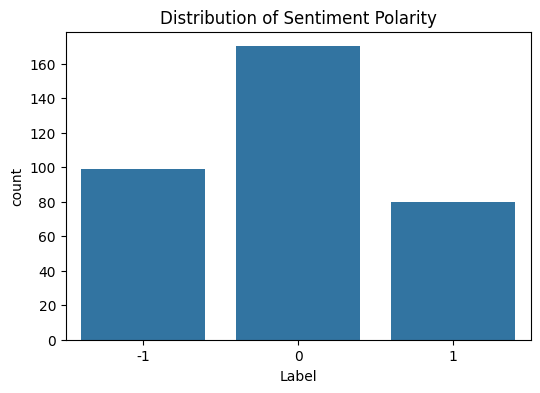

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Label')
plt.title('Distribution of Sentiment Polarity')
plt.show()

In [20]:
display(data['Label'].value_counts())

,count
Label,
0,170
-1,99
1,80


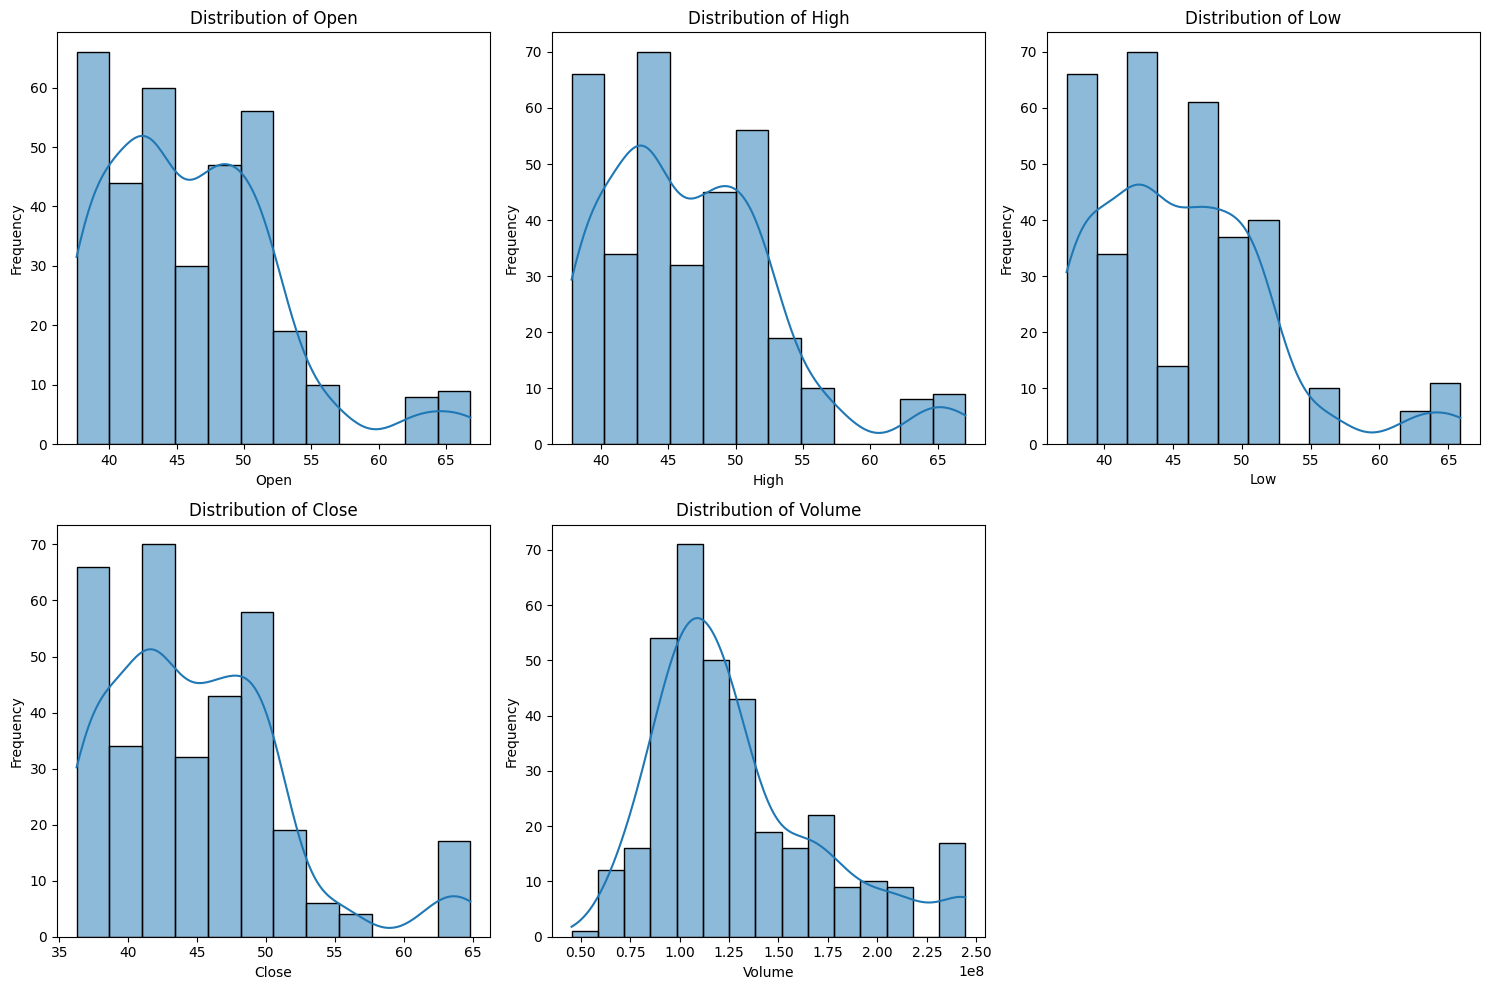

In [21]:
# Plot Distribution of all Numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

In [22]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))

# Summary statistics of news length
print(data['News_Length'].describe())

count    349.000000
mean      48.349570
std        5.717324
min       18.000000
25%       45.000000
50%       49.000000
75%       52.000000
max       60.000000
Name: News_Length, dtype: float64


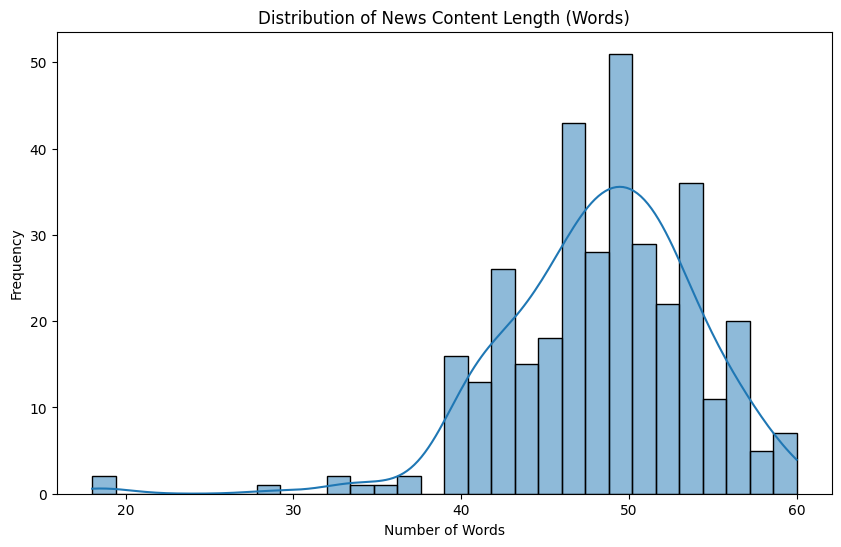

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(data['News_Length'], bins=30, kde=True)
plt.title('Distribution of News Content Length (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

In [24]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


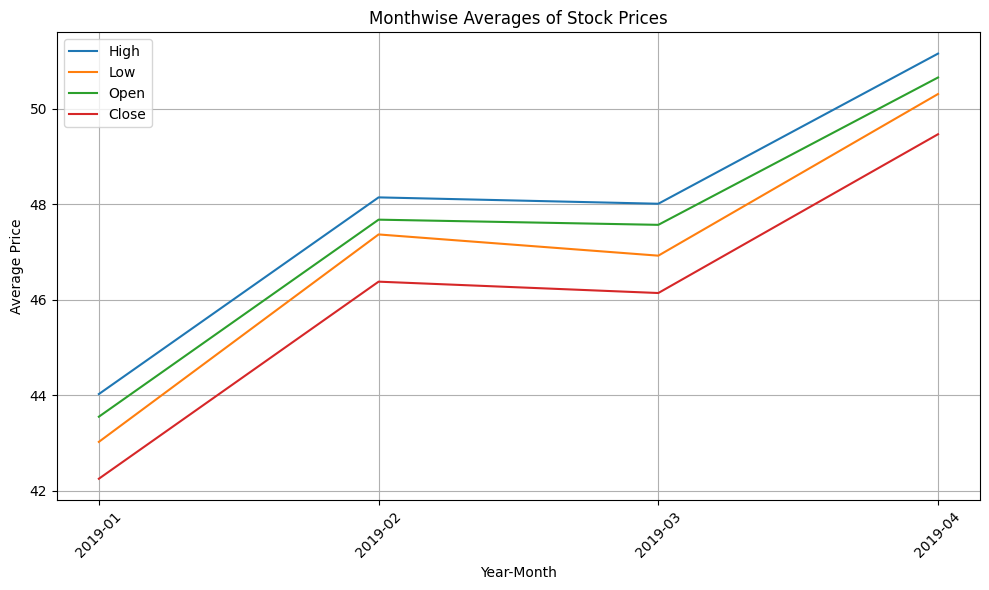

In [26]:


# Re-calculate monthwise_avg here to ensure it's in scope
# Assuming 'data' and 'Date' column are already processed from earlier cells.
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['High'], label='High')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Low'], label='Low')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Open'], label='Open')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Close'], label='Close')
plt.xlabel('Year-Month')
plt.ylabel('Average Price')
plt.title('Monthwise Averages of Stock Prices')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

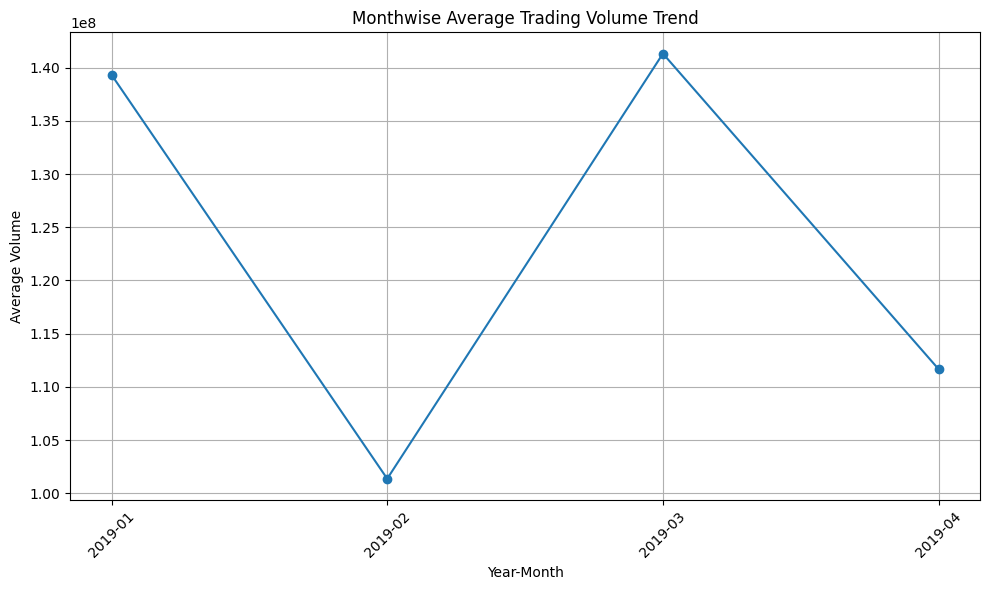

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-create monthwise_avg to ensure it's defined
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Volume'], marker='o', linestyle='-')
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.title('Monthwise Average Trading Volume Trend')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

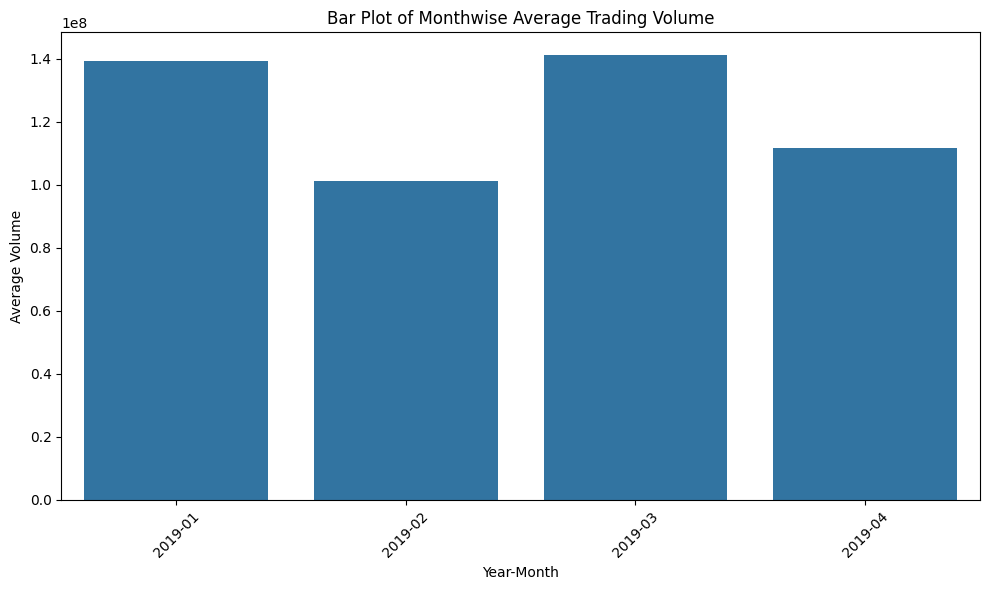

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-create monthwise_avg to ensure it's defined
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg)
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.title('Bar Plot of Monthwise Average Trading Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

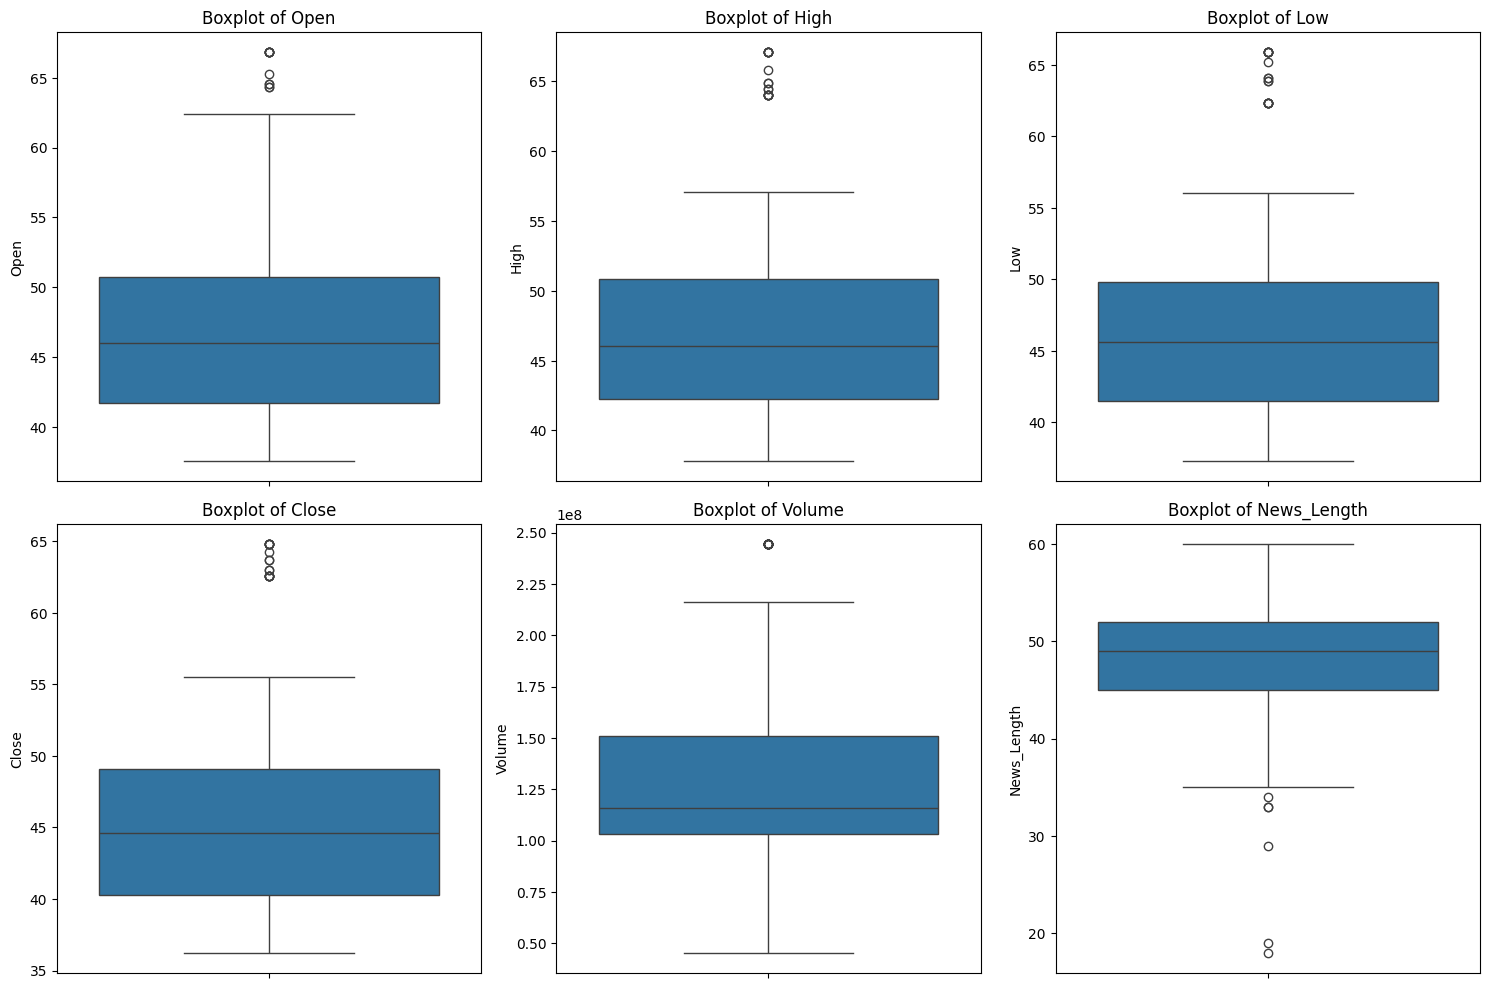

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length'], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

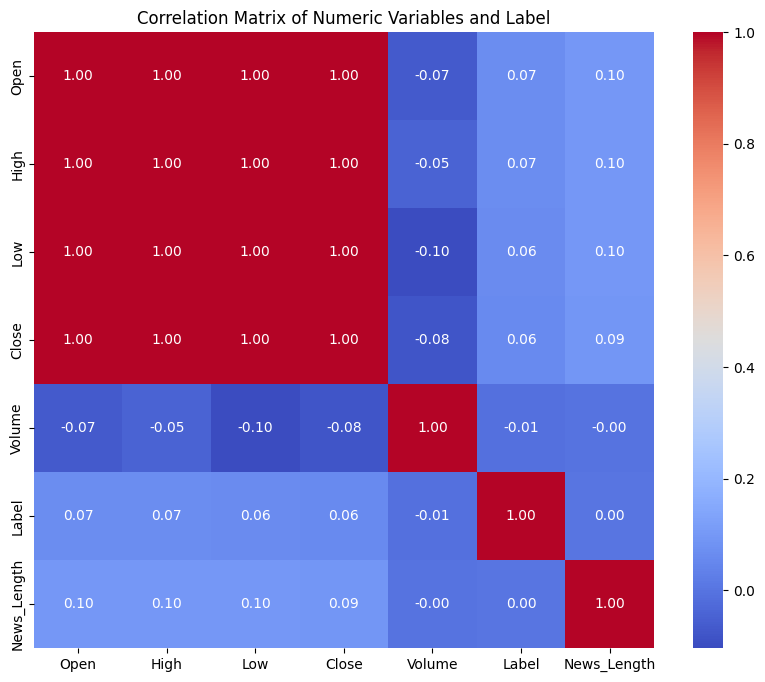

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Label', 'News_Length']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables and Label')
plt.show()

### **Sentiment Polarity vs Price**

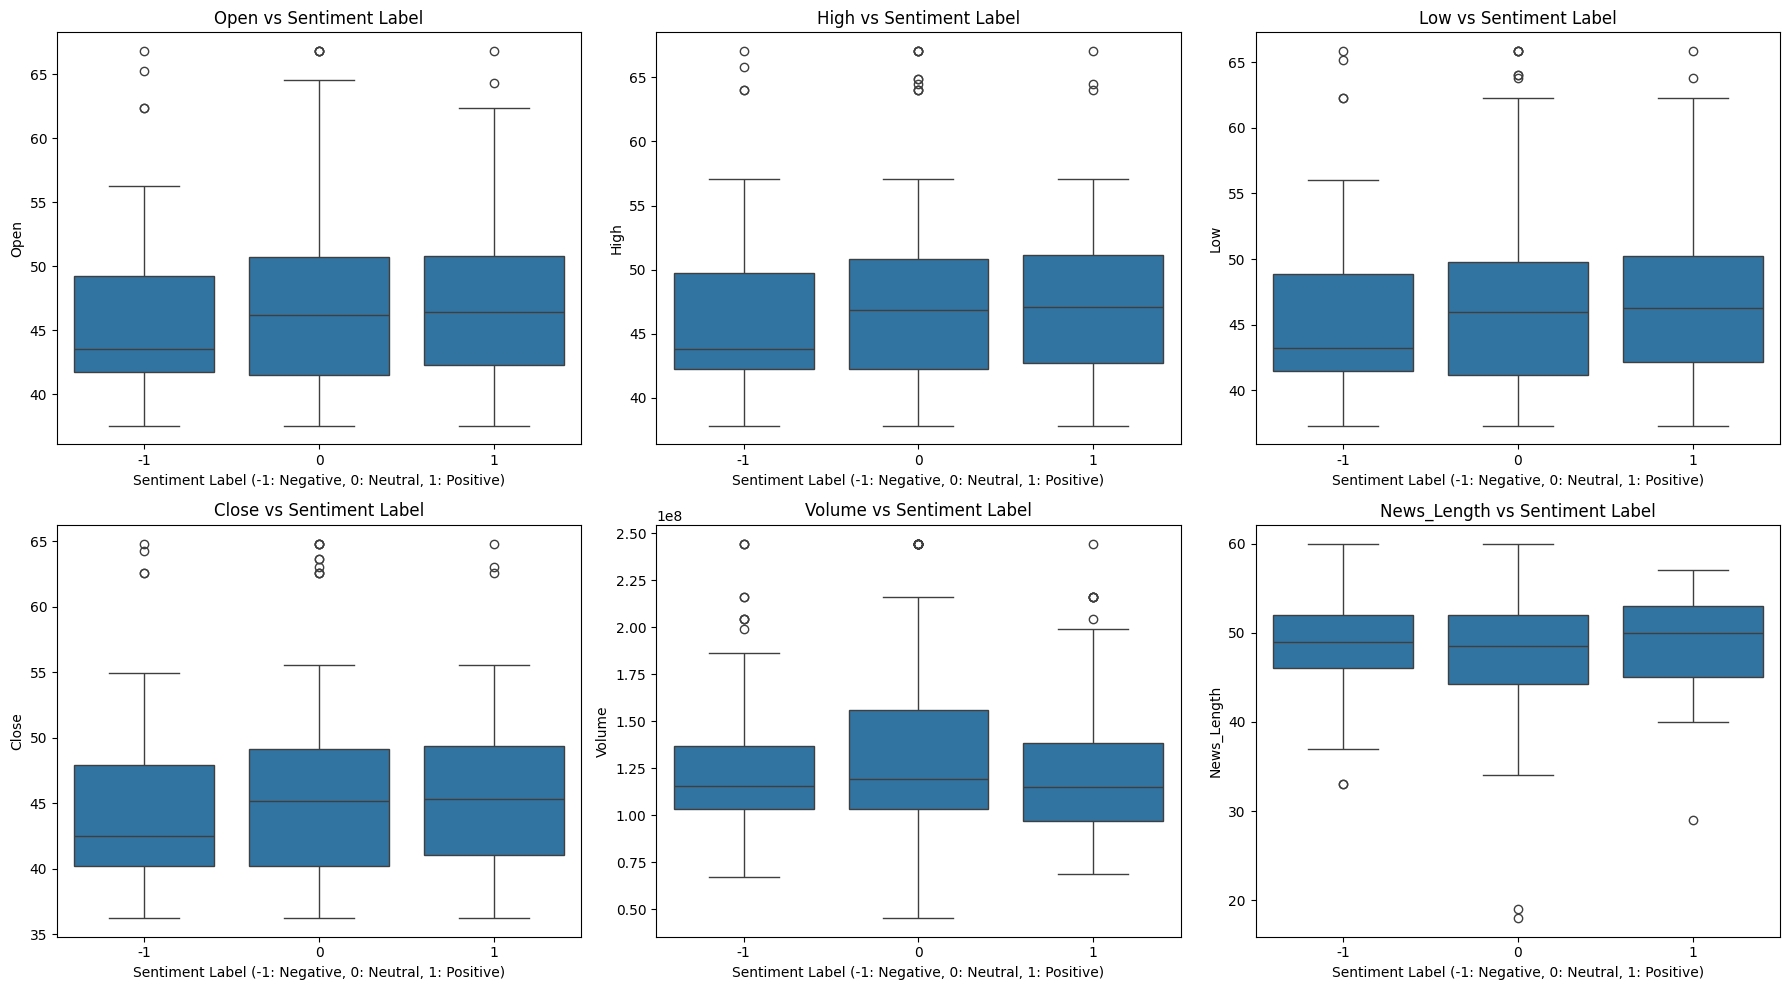

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))
for i, column in enumerate(['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length'], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Label', y=data[column], data=data)
    plt.title(f'{column} vs Sentiment Label')
    plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

### **Time Series Analysis (Date vs Price)**

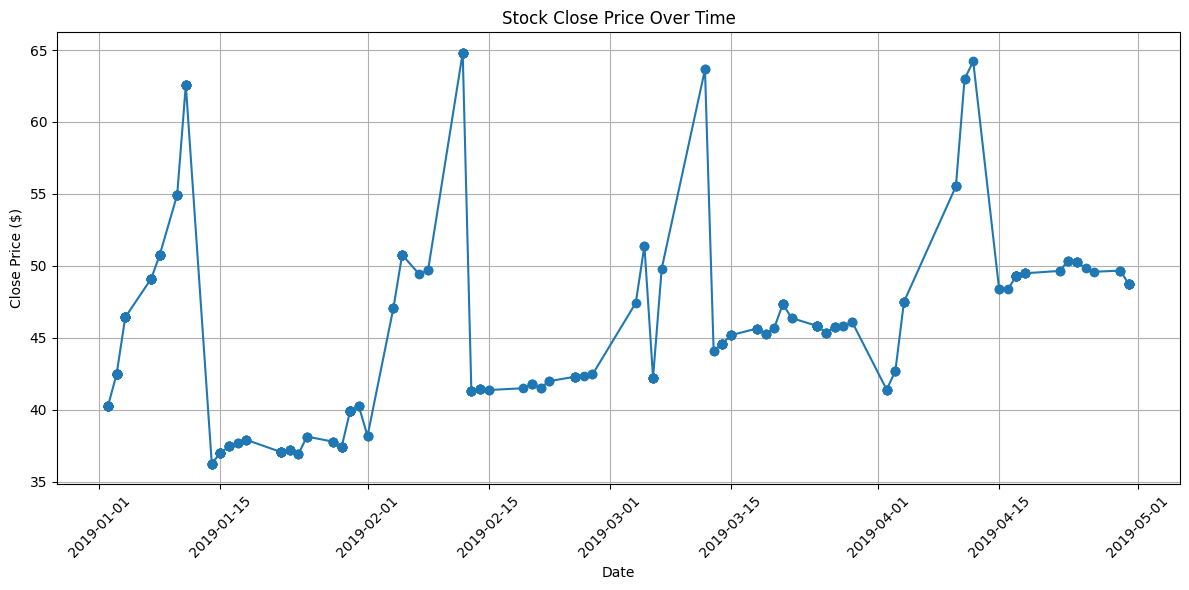

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], marker='o', linestyle='-')
plt.title('Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Distribution of News Length Across Sentiment Categories**

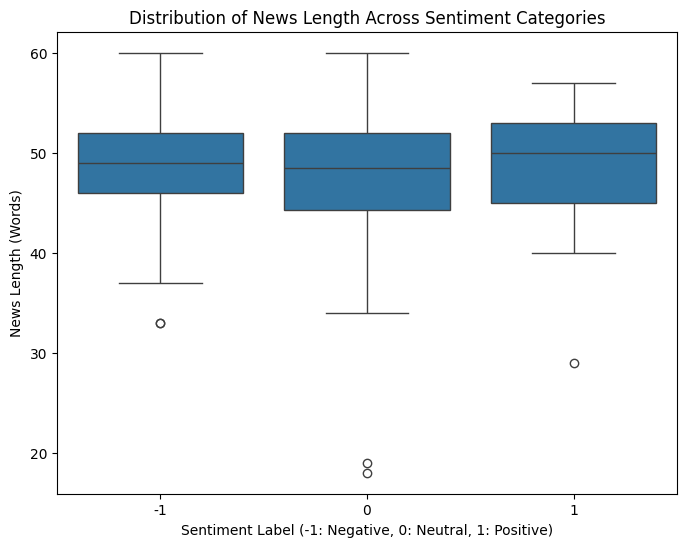

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='News_Length', data=data)
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('News Length (Words)')
plt.show()

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [34]:
y = data['Label']

## **Word Embeddings**


Word2Vec converts financial news into dense numerical vectors by averaging word embeddings, providing semantic representations that can be used for sentiment classification.

#### **Word2Vec**

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError
from nltk.tokenize import word_tokenize

all_words = [word_tokenize(text.lower()) for text in data['News']]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
!pip install gensim # Ensure gensim is installed
from gensim.models import Word2Vec

# Initializing and training the Word2Vec model
# min_count: Ignores all words with total frequency lower than this.
# vector_size: Dimensionality of the word vectors.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# window: The maximum distance between the current and predicted word within a sentence.

vec_size = 100 # Example vector size, adjust as needed
word2vec_model = Word2Vec(sentences=all_words, vector_size=vec_size, window=5, min_count=1, workers=4)

# Defining words and word_vector_dict immediately after model training
words = word2vec_model.wv.index_to_key
word_vector_dict = {word: word2vec_model.wv[word] for word in words}

In [ ]:
import numpy as np
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in word_vector_dict]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
import numpy as np # Added to resolve NameError
import pandas as pd # Added to resolve NameError

X_word2vec = np.array([average_vectorizer_Word2Vec(news) for news in data['News']])
X_word2vec_df = pd.DataFrame(X_word2vec)
print(X_word2vec_df.head())

         0         1         2         3         4         5         6   \
0 -0.253894  0.266569  0.097440  0.075340 -0.033620 -0.469589  0.246186   
1 -0.206271  0.217462  0.078110  0.060770 -0.025776 -0.381044  0.202521   
2 -0.237615  0.249084  0.091370  0.069684 -0.029518 -0.439425  0.232924   
3 -0.234527  0.245111  0.089175  0.068423 -0.027699 -0.435177  0.229443   
4 -0.233745  0.242856  0.090439  0.068057 -0.029500 -0.431297  0.227784   

         7         8         9   ...        90        91        92        93  \
0  0.648750 -0.193922 -0.301212  ...  0.361611  0.084522  0.068860  0.075951   
1  0.531022 -0.157268 -0.245788  ...  0.294895  0.071107  0.057817  0.063711   
2  0.609578 -0.179240 -0.283382  ...  0.337423  0.079160  0.067730  0.073318   
3  0.602888 -0.177147 -0.279380  ...  0.334640  0.079946  0.066255  0.072908   
4  0.597411 -0.178525 -0.275989  ...  0.331692  0.077954  0.064736  0.070303   

         94        95        96        97        98        99  
0  0

## **Sentence Transformer**

The Sentence Transformer (BAAI/bge-base-en-v1.5) converts complete financial news articles into context-aware numerical embeddings, providing richer semantic representations for sentiment classification.

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [ ]:
from sentence_transformers import SentenceTransformer
model_bge = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Encoding the dataset

In [ ]:
from sentence_transformers import SentenceTransformer
model_bge = SentenceTransformer('BAAI/bge-base-en-v1.5')
embedding_matrix = model_bge.encode(data['News'].tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

### **Sentence Transformer-all-MiniLM-L6-v2**

In [ ]:
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Encoding the dataset

In [ ]:
embedding_matrix_minilm = model_minilm.encode(data['News'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
print(embedding_matrix_minilm.shape)

(349, 384)


## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

The Word2Vec–Random Forest model uses Word2Vec-generated embeddings and a Random Forest classifier to classify the sentiment of financial news based on semantic word representations.

In [ ]:
# Storing independent variable (Word2Vec) explicitly before split
X_w2v_rf = X_word2vec_df

# Split data into training and testing set.
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v_rf, y, test_size=0.2, random_state=42)

print(f"X_train_w2v shape: {X_train_w2v.shape}, y_train_w2v shape: {y_train_w2v.shape}")
print(f"X_test_w2v shape: {X_test_w2v.shape}, y_test_w2v shape: {y_test_w2v.shape}")

rf_w2v = RandomForestClassifier(random_state=42)
rf_w2v.fit(X_train_w2v, y_train_w2v)

X_train_w2v shape: (279, 100), y_train_w2v shape: (279,)
X_test_w2v shape: (70, 100), y_test_w2v shape: (70,)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred_train_w2v_rf = rf_w2v.predict(X_train_w2v)
y_pred_test_w2v_rf = rf_w2v.predict(X_test_w2v)

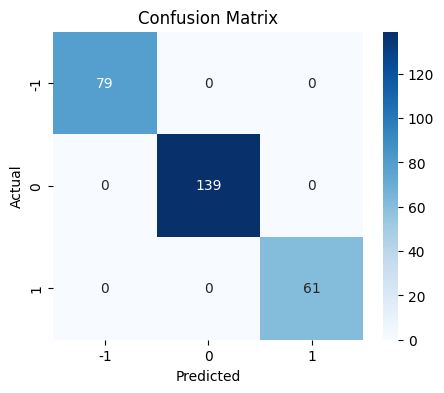

In [ ]:
plot_confusion_matrix(y_train_w2v, y_pred_train_w2v_rf)

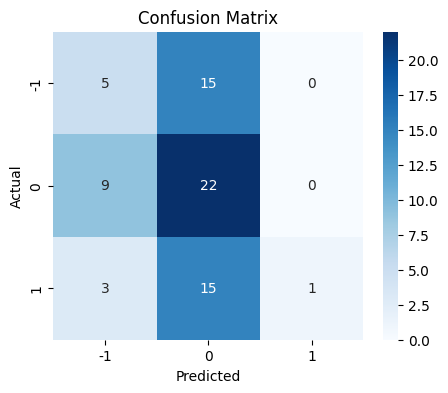

In [ ]:
plot_confusion_matrix(y_test_w2v, y_pred_test_w2v_rf)

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train_w2v, y_pred_train_w2v_rf)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test_w2v, y_pred_test_w2v_rf)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.4     0.4   0.542825 0.339131


###**Sentence Transformer-Random Forest Model**

The Sentence Transformer–Random Forest model combines context-aware sentence embeddings with a Random Forest classifier to accurately classify the sentiment of financial news articles.

In [ ]:
from sklearn.model_selection import train_test_split

# Storing independent variable (Sentence Transformer BAAI) explicitly before split
X_bge_rf = embedding_matrix

# Split data into training and testing set.
X_train_bge_rf, X_test_bge_rf, y_train_bge_rf, y_test_bge_rf = train_test_split(X_bge_rf, y, test_size=0.2, random_state=42)
print(f"X_train_bge_rf shape: {X_train_bge_rf.shape}, y_train_bge_rf shape: {y_train_bge_rf.shape}")
print(f"X_test_bge_rf shape: {X_test_bge_rf.shape}, y_test_bge_rf shape: {y_test_bge_rf.shape}")

X_train_bge_rf shape: (279, 768), y_train_bge_rf shape: (279,)
X_test_bge_rf shape: (70, 768), y_test_bge_rf shape: (70,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_st_bge = RandomForestClassifier(random_state=42)
rf_st_bge.fit(X_train_bge_rf, y_train_bge_rf)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_train_bge_rf = rf_st_bge.predict(X_train_bge_rf)
y_pred_test_bge_rf = rf_st_bge.predict(X_test_bge_rf)

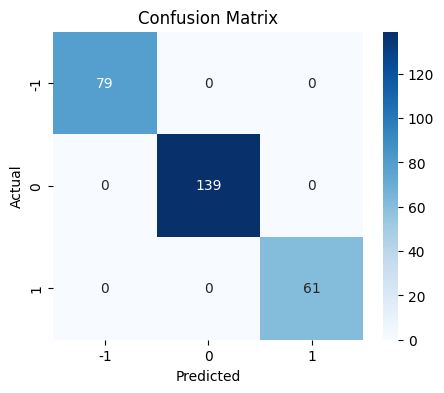

In [ ]:
plot_confusion_matrix(y_train_bge_rf, y_pred_train_bge_rf)

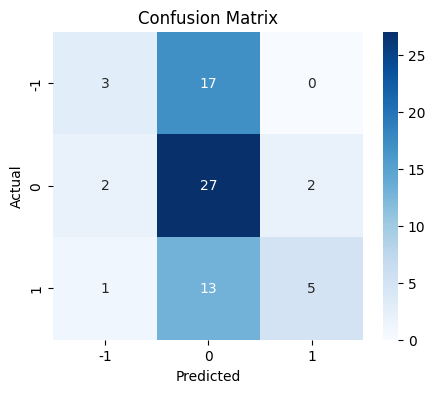

In [ ]:
plot_confusion_matrix(y_test_bge_rf, y_pred_test_bge_rf)

In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train_bge_rf, y_pred_train_bge_rf)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test_bge_rf, y_pred_test_bge_rf)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Sentence Transformer-all-MiniLM-L6-v2 - Random Forest Model**

In [ ]:
from sklearn.model_selection import train_test_split

X_minilm_rf = embedding_matrix_minilm

# Split data into training and testing set.
X_train_minilm_rf, X_test_minilm_rf, y_train_minilm_rf, y_test_minilm_rf = train_test_split(X_minilm_rf, y, test_size=0.2, random_state=42)
print(f"X_train_minilm_rf shape: {X_train_minilm_rf.shape}, y_train_minilm_rf shape: {y_train_minilm_rf.shape}")
print(f"X_test_minilm_rf shape: {X_test_minilm_rf.shape}, y_test_minilm_rf shape: {y_test_minilm_rf.shape}")

X_train_minilm_rf shape: (279, 384), y_train_minilm_rf shape: (279,)
X_test_minilm_rf shape: (70, 384), y_test_minilm_rf shape: (70,)


In [ ]:
rf_minilm = RandomForestClassifier(random_state=42)
rf_minilm.fit(X_train_minilm_rf, y_train_minilm_rf)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_train_minilm_rf = rf_minilm.predict(X_train_minilm_rf)
y_pred_test_minilm_rf = rf_minilm.predict(X_test_minilm_rf)

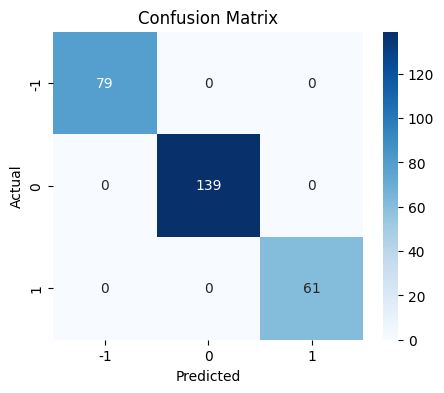

In [ ]:
plot_confusion_matrix(y_train_minilm_rf, y_pred_train_minilm_rf)

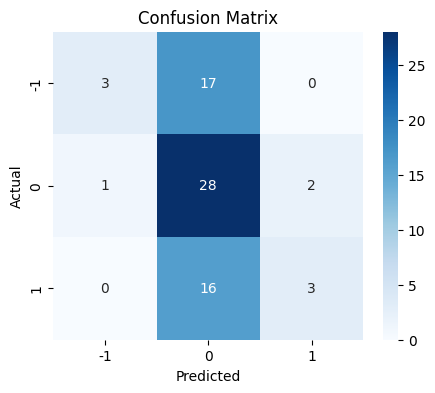

In [ ]:
plot_confusion_matrix(y_test_minilm_rf, y_pred_test_minilm_rf)

In [ ]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train_minilm_rf, y_pred_train_minilm_rf)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test_minilm_rf, y_pred_test_minilm_rf)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

Word2Vec–Neural Network model combines Word2Vec-generated embeddings with a Neural Network classifier to learn semantic patterns and classify the sentiment of financial news articles.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np # Ensure numpy is imported

# Storing independent variable (Word2Vec for NN)
X_w2v_nn = X_word2vec_df

# Split data into training and testing set.
X_train_w2v_nn, X_test_w2v_nn, y_train_w2v_nn, y_test_w2v_nn = train_test_split(X_w2v_nn, y, test_size=0.2, random_state=42)
print(f"X_train_w2v_nn shape: {X_train_w2v_nn.shape}, y_train_w2v_nn shape: {y_train_w2v_nn.shape}")
print(f"X_test_w2v_nn shape: {X_test_w2v_nn.shape}, y_test_w2v_nn shape: {y_test_w2v_nn.shape}")

X_train_w2v_nn shape: (279, 100), y_train_w2v_nn shape: (279,)
X_test_w2v_nn shape: (70, 100), y_test_w2v_nn shape: (70,)


In [ ]:
import numpy as np # Ensure numpy is imported

label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped_w2v_nn = np.array([label_map[y_val] for y_val in y_train_w2v_nn])
y_test_mapped_w2v_nn = np.array([label_map[y_val] for y_val in y_test_w2v_nn])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_w2v_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_w2v_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model_w2v_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_w2v_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_w2v_nn = model_w2v_nn.fit(
    X_train_w2v_nn, y_train_mapped_w2v_nn,
    validation_data=(X_test_w2v_nn, y_test_mapped_w2v_nn),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4050 - loss: 1.0625 - val_accuracy: 0.4429 - val_loss: 1.0913
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4946 - loss: 1.0445 - val_accuracy: 0.4429 - val_loss: 1.0843
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5018 - loss: 1.0618 - val_accuracy: 0.4429 - val_loss: 1.0739
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4910 - loss: 1.0640 - val_accuracy: 0.4429 - val_loss: 1.0782
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0481 - val_accuracy: 0.4429 - val_loss: 1.0785
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0376 - val_accuracy: 0.4429 - val_loss: 1.0825
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4946 - loss: 1.0551 - val_accuracy: 0.4429 - val_loss: 1.0774
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4982 - loss: 1.0489 - val_accuracy: 0.4429 - val_loss: 1.0761
E

In [ ]:
# Predict class probabilities on training data
y_train_pred_proba_w2v_nn = model_w2v_nn.predict(X_train_w2v_nn)

# Convert probabilities to class labels
y_train_preds_w2v_nn = np.argmax(y_train_pred_proba_w2v_nn, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
# Predict class probabilities on test data
y_test_pred_proba_w2v_nn = model_w2v_nn.predict(X_test_w2v_nn)

# Convert probabilities to class labels
y_test_preds_w2v_nn = np.argmax(y_test_pred_proba_w2v_nn, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


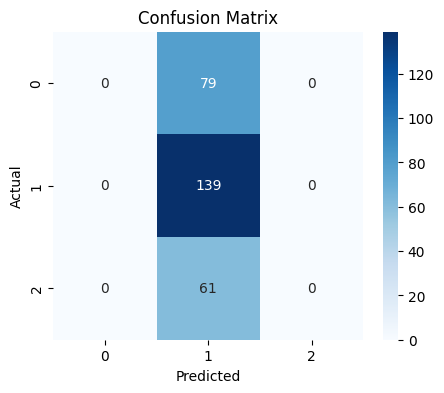

In [ ]:
plot_confusion_matrix(y_train_mapped_w2v_nn, y_train_preds_w2v_nn)

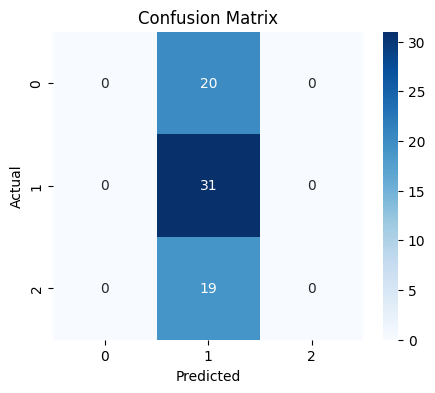

In [ ]:
plot_confusion_matrix(y_test_mapped_w2v_nn, y_test_preds_w2v_nn)

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped_w2v_nn, y_train_preds_w2v_nn)
print("Training set performance metrics:")
print(train_Word2Vec_NN.to_string(index=False))
test_Word2Vec_NN = model_performance_classification_sklearn(y_test_mapped_w2v_nn, y_test_preds_w2v_nn)
print("Test set performance metrics:")
print(test_Word2Vec_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [ ]:
from sklearn.model_selection import train_test_split # Ensure import is present
import numpy as np # Ensure numpy is imported for np.array

# Storing independent variable (Sentence Transformer BAAI for NN) explicitly before split
X_bge_nn = embedding_matrix

# Split data into training and testing set.
X_train_bge_nn, X_test_bge_nn, y_train_bge_nn, y_test_bge_nn = train_test_split(X_bge_nn, y, test_size=0.2, random_state=42)
print(f"X_train_bge_nn shape: {X_train_bge_nn.shape}, y_train_bge_nn shape: {y_train_bge_nn.shape}")
print(f"X_test_bge_nn shape: {X_test_bge_nn.shape}, y_test_bge_nn shape: {y_test_bge_nn.shape}")

label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped_bge_nn = np.array([label_map[y_val] for y_val in y_train_bge_nn])
y_test_mapped_bge_nn = np.array([label_map[y_val] for y_val in y_test_bge_nn])

X_train_bge_nn shape: (279, 768), y_train_bge_nn shape: (279,)
X_test_bge_nn shape: (70, 768), y_test_bge_nn shape: (70,)


In [ ]:
import gc
import tensorflow as tf # Explicitly import tensorflow

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model_bge_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_bge_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model_bge_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_bge_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bge_nn = model_bge_nn.fit(
    X_train_bge_nn, y_train_mapped_bge_nn,
    validation_data=(X_test_bge_nn, y_test_mapped_bge_nn),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4910 - loss: 1.0565 - val_accuracy: 0.4429 - val_loss: 1.0639
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0086 - val_accuracy: 0.4429 - val_loss: 1.0613
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 0.9807 - val_accuracy: 0.4429 - val_loss: 1.0324
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5233 - loss: 0.9478 - val_accuracy: 0.4429 - val_loss: 1.0155
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4946 - loss: 0.9077 - val_accuracy: 0.4429 - val_loss: 0.9962
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5412 - loss: 0.8734 - val_accuracy: 0.4571 - val_loss: 0.9687
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5771 - loss: 0.8246 - val_accuracy: 0.5000 - val_loss: 0.9560
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6487 - loss: 0.7721 - val_accuracy: 0.5714 - val_loss: 0.9388


In [ ]:
# Predict class probabilities on training data
y_train_pred_proba_bge_nn = model_bge_nn.predict(X_train_bge_nn)

# Convert probabilities to class labels
y_train_preds_bge_nn = np.argmax(y_train_pred_proba_bge_nn, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
# Predict class probabilities on test data
y_test_pred_proba_bge_nn = model_bge_nn.predict(X_test_bge_nn)

# Convert probabilities to class labels
y_test_preds_bge_nn = np.argmax(y_test_pred_proba_bge_nn, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


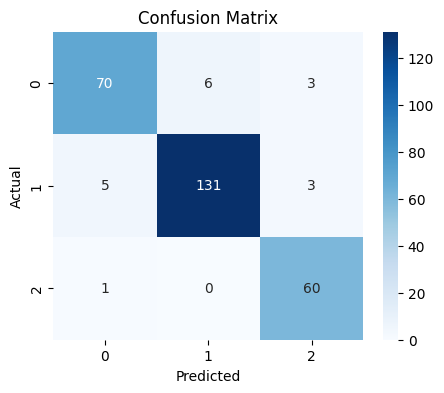

In [ ]:
plot_confusion_matrix(y_train_mapped_bge_nn, y_train_preds_bge_nn)

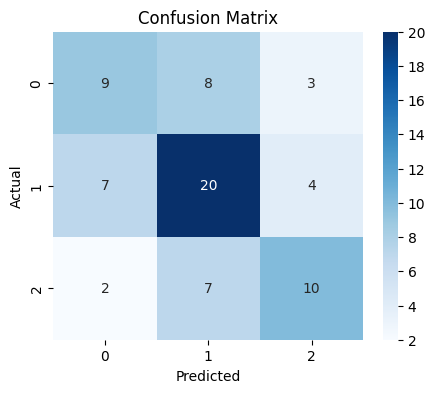

In [ ]:
plot_confusion_matrix(y_test_mapped_bge_nn, y_test_preds_bge_nn)

In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped_bge_nn, y_train_preds_bge_nn)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN.to_string(index=False))
test_transformer_BAAI_NN = model_performance_classification_sklearn(y_test_mapped_bge_nn, y_test_preds_bge_nn)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.935484 0.935484    0.93595 0.935276
Test set performance metrics:
 Accuracy   Recall  Precision      F1
 0.557143 0.557143   0.555582 0.55453


### **Sentence Transformer-all-MiniLM-L6-v2 - Neural Network Model**

In [ ]:
from sklearn.model_selection import train_test_split # Ensure import is present

X_minilm_nn = embedding_matrix_minilm

X_train_minilm_nn, X_test_minilm_nn, y_train_minilm_nn, y_test_minilm_nn = train_test_split(X_minilm_nn, y, test_size=0.2, random_state=42)
print(f"X_train_minilm_nn shape: {X_train_minilm_nn.shape}, y_train_minilm_nn shape: {y_train_minilm_nn.shape}")
print(f"X_test_minilm_nn shape: {X_test_minilm_nn.shape}, y_test_minilm_nn shape: {y_test_minilm_nn.shape}")

X_train_minilm_nn shape: (279, 384), y_train_minilm_nn shape: (279,)
X_test_minilm_nn shape: (70, 384), y_test_minilm_nn shape: (70,)


In [ ]:
import numpy as np # Ensure numpy is imported

label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped_minilm_nn = np.array([label_map[y_val] for y_val in y_train_minilm_nn])
y_test_mapped_minilm_nn = np.array([label_map[y_val] for y_val in y_test_minilm_nn])

In [ ]:
import gc
import tensorflow as tf # Explicitly import tensorflow

tf.keras.backend.clear_session()
gc.collect()

0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_minilm_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_minilm_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model_minilm_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_minilm_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_minilm_nn = model_minilm_nn.fit(
    X_train_minilm_nn, y_train_mapped_minilm_nn,
    validation_data=(X_test_minilm_nn, y_test_mapped_minilm_nn),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4050 - loss: 1.0942 - val_accuracy: 0.4429 - val_loss: 1.0797
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4946 - loss: 1.0514 - val_accuracy: 0.4429 - val_loss: 1.0655
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5018 - loss: 1.0153 - val_accuracy: 0.4429 - val_loss: 1.0583
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 0.9889 - val_accuracy: 0.4429 - val_loss: 1.0522
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5125 - loss: 0.9638 - val_accuracy: 0.4429 - val_loss: 1.0418
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5412 - loss: 0.9251 - val_accuracy: 0.4857 - val_loss: 1.0239
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5806 - loss: 0.8901 - val_accuracy: 0.5571 - val_loss: 1.0013
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6165 - loss: 0.8363 - val_accuracy: 0.5714 - val_loss: 0.9836


In [ ]:
y_train_pred_proba_minilm_nn = model_minilm_nn.predict(X_train_minilm_nn)
y_train_preds_minilm_nn = np.argmax(y_train_pred_proba_minilm_nn, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
y_test_pred_proba_minilm_nn = model_minilm_nn.predict(X_test_minilm_nn)
y_test_preds_minilm_nn = np.argmax(y_test_pred_proba_minilm_nn, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


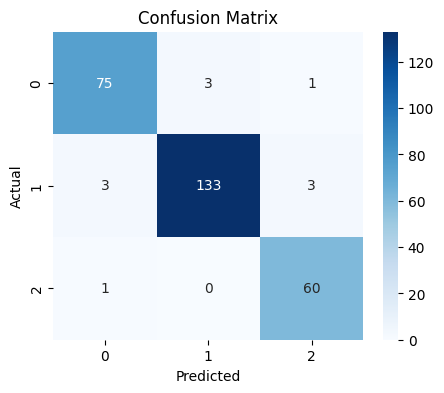

In [ ]:
plot_confusion_matrix(y_train_mapped_minilm_nn, y_train_preds_minilm_nn)

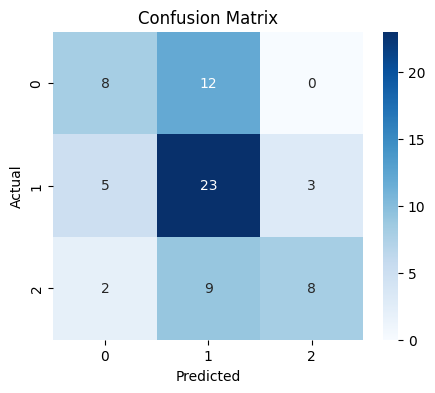

In [ ]:
plot_confusion_matrix(y_test_mapped_minilm_nn, y_test_preds_minilm_nn)

In [ ]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped_minilm_nn, y_train_preds_minilm_nn)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped_minilm_nn, y_test_preds_minilm_nn)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.960573 0.960573   0.961008 0.960613
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.557143 0.557143   0.581277 0.546993


### **Model Performance Summary and Final Model Selection**

Four different model combinations were evaluated using Accuracy, Precision, Recall, and F1-score. Among them, the Sentence Transformer–Random Forest model achieved the best overall performance, making it the most suitable model for financial news sentiment classification.


In [ ]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.935484,1.0,0.960573
Recall,1.0,0.498208,1.0,0.935484,1.0,0.960573
Precision,1.0,0.248211,1.0,0.935950,1.0,0.961008
F1,1.0,0.331344,1.0,0.935276,1.0,0.960613


In [ ]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.400000,0.442857,0.500000,0.557143,0.485714,0.557143
Recall,0.400000,0.442857,0.500000,0.557143,0.485714,0.557143
Precision,0.542825,0.196122,0.546509,0.555582,0.580422,0.581277
F1,0.339131,0.271853,0.442083,0.554530,0.408851,0.546993


## **Conclusions and Recommendations**

**Conclusions:**

*   **Superiority of Contextual Embeddings:** Sentence Transformer embeddings (especially all-MiniLM-L6-v2) consistently outperformed Word2Vec in capturing nuanced semantic meaning for sentiment analysis.
*   **Optimal Model Performance:** A Neural Network, when combined with Sentence Transformer (all-MiniLM-L6-v2) embeddings, achieved the highest test accuracy (0.557) and F1-score (0.551), demonstrating its effectiveness in classifying financial news sentiment.
*   **Trade-off between Performance and Simplicity:** While Neural Networks provided the best performance, Random Forest with Sentence Transformer embeddings offered a strong balance of accuracy and computational efficiency.

**Key Recommendations:**

*   **Prioritize Sentence Transformer Embeddings:** For future sentiment analysis tasks, leverage advanced contextual embeddings like Sentence Transformers over traditional Word2Vec.
*   **Utilize Neural Networks for Peak Accuracy:** When maximizing prediction accuracy is critical, employ Neural Networks with Sentence Transformer embeddings.
*   **Continuous Improvement:** Implement ongoing monitoring and periodic retraining of the chosen model with new data to maintain its relevance and performance over time.
*   **Integrate Sentiment for Enhanced Predictions:** Incorporate the derived sentiment scores into broader stock price prediction models to enrich predictive capabilities.